In [4]:
# Install FastAI (if not already installed)
!pip install -U fastai

# Import necessary libraries
from fastai.vision.all import *
from fastai.tabular.all import *
import pandas as pd
from pathlib import Path

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit

In [7]:
# Load the anemia dataset
csv_path = "/content/drive/MyDrive/anemia_cleaned.csv"  # Update path if needed
df = pd.read_csv(csv_path)

# Define continuous variables & target
cont_vars = ['Hemoglobin', 'MCH', 'MCHC', 'MCV']
dep_var = 'Result'  # Target column

# Create DataLoaders for tabular dataset
tab_data = TabularDataLoaders.from_df(df, path='.',
                                      procs=[FillMissing, Normalize],
                                      cont_names=cont_vars,
                                      y_names=dep_var, y_block=CategoryBlock(),
                                      valid_pct=0.2, bs=32)

# Function to train a tabular model
def train_tabular_model(layers, filename):
    learn = tabular_learner(tab_data, layers=layers, metrics=accuracy)
    learn.fit_one_cycle(5)
    learn.export(f'/content/{filename}.pkl')
    return learn

# Train three tabular models with different architectures
learn_tab1 = train_tabular_model([200, 100], "tabular_model1")
learn_tab2 = train_tabular_model([300, 150], "tabular_model2")
learn_tab3 = train_tabular_model([400, 200], "tabular_model3")

epoch,train_loss,valid_loss,accuracy,time
0,0.380952,0.253333,0.887324,00:01
1,0.283417,0.233203,0.919014,00:00
2,0.270917,0.202461,0.922535,00:00
3,0.237313,0.196800,0.919014,00:00
4,0.239253,0.211910,0.911972,00:00


epoch,train_loss,valid_loss,accuracy,time
0,0.469545,0.229200,0.915493,00:00
1,0.301982,0.201990,0.908451,00:00
2,0.269628,0.186271,0.919014,00:00
3,0.239774,0.189476,0.904930,00:00
4,0.226734,0.188489,0.904930,00:00


epoch,train_loss,valid_loss,accuracy,time
0,0.342539,0.236205,0.894366,00:00
1,0.302861,0.195577,0.894366,00:00
2,0.270707,0.191524,0.922535,00:00
3,0.233335,0.195266,0.911972,00:00
4,0.233652,0.198125,0.894366,00:00


In [8]:
import os

# List all files in the current directory
print(os.listdir('/content'))

['.config', 'tabular_model2.pkl', 'drive', 'tabular_model1.pkl', 'tabular_model3.pkl', 'sample_data']


In [9]:
from fastai.tabular.all import load_learner

# Load all three models
models = [
    load_learner('/content/tabular_model1.pkl'),
    load_learner('/content/tabular_model2.pkl'),
    load_learner('/content/tabular_model3.pkl')
]

/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you t

In [10]:
from fastai.tabular.all import load_learner
import pandas as pd

# Load all three tabular models
tabular_models = [
    load_learner('/content/tabular_model1.pkl'),
    load_learner('/content/tabular_model2.pkl'),
    load_learner('/content/tabular_model3.pkl')
]

# Prediction function with ensemble
def predict_tabular_ensemble(input_data):
    df = pd.DataFrame([input_data])

    # Ensure correct column order
    df = df[tabular_models[0].dls.x_names]

    # Get predictions from all three models
    preds = []
    for model in tabular_models:
        pred, pred_idx, probs = model.predict(df.iloc[0])
        preds.append(probs)

    # Average the probabilities from all models
    avg_probs = sum(preds) / len(preds)

    # Get final prediction
    final_pred_idx = avg_probs.argmax()
    final_pred = tabular_models[0].dls.vocab[final_pred_idx]

    return final_pred, avg_probs[final_pred_idx].item()

# Test it
sample_cbc = {'Hemoglobin': 10.5, 'MCH': 22.1, 'MCHC': 28.7, 'MCV': 72.4}
print(predict_tabular_ensemble(sample_cbc))

/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you t

(np.int8(1), 0.9994440674781799)


In [11]:
# Sample CBC test cases
sample_cases = [
    {'Hemoglobin': 11.2, 'MCH': 24.0, 'MCHC': 30.2, 'MCV': 78.0},  # Case 1
    {'Hemoglobin': 9.5, 'MCH': 21.5, 'MCHC': 28.0, 'MCV': 70.5},   # Case 2
    {'Hemoglobin': 13.0, 'MCH': 27.2, 'MCHC': 32.5, 'MCV': 82.0},  # Case 3
    {'Hemoglobin': 8.8, 'MCH': 19.7, 'MCHC': 27.0, 'MCV': 68.0},   # Case 4
    {'Hemoglobin': 12.4, 'MCH': 26.5, 'MCHC': 31.5, 'MCV': 80.0}   # Case 5
]

# Run predictions on all cases
for i, sample in enumerate(sample_cases):
    pred, confidence = predict_tabular_ensemble(sample)
    print(f"Sample {i+1}: Prediction = {pred}, Confidence = {confidence:.4f}")

Sample 1: Prediction = 1, Confidence = 0.9924


Sample 2: Prediction = 1, Confidence = 1.0000


Sample 3: Prediction = 0, Confidence = 0.5801


Sample 4: Prediction = 1, Confidence = 1.0000


Sample 5: Prediction = 1, Confidence = 0.8056


In [12]:
print(df.columns)

Index(['Hemoglobin', 'MCH', 'MCHC', 'MCV', 'Result'], dtype='object')


In [13]:
df.get('result')

In [14]:
print(df.head())  # See if 'result' is present

   Hemoglobin   MCH  MCHC   MCV  Result
0        14.9  22.7  29.1  83.7       0
1        15.9  25.4  28.3  72.0       0
2         9.0  21.5  29.6  71.2       1
3        14.9  16.0  31.4  87.5       0
4        14.7  22.0  28.2  99.5       0


In [15]:
df.columns = df.columns.str.strip()  # Removes extra spaces

In [16]:
df['Result']  # Instead of df['result']

,Result
0,0
1,0
2,1
3,0
4,0
...,...
1416,1
1417,1
1418,1
1419,0


In [17]:
df.columns = df.columns.str.lower()
print(df.columns)  # This should show 'result' in lowercase

df['result']  # Now this should work

Index(['hemoglobin', 'mch', 'mchc', 'mcv', 'result'], dtype='object')


,result
0,0
1,0
2,1
3,0
4,0
...,...
1416,1
1417,1
1418,1
1419,0


In [18]:
df.columns = df.columns.str.strip()  # Removes leading/trailing spaces

In [19]:
print(df.columns.tolist())  # This will display all column names exactly as they are

['hemoglobin', 'mch', 'mchc', 'mcv', 'result']


In [20]:
samples = [
    {'Hemoglobin': 12.1, 'MCH': 27.5, 'MCHC': 33.0, 'MCV': 83.2},  # Normal range
    {'Hemoglobin': 9.8, 'MCH': 21.9, 'MCHC': 28.5, 'MCV': 70.1},   # Possible anemia
    {'Hemoglobin': 14.3, 'MCH': 29.2, 'MCHC': 34.1, 'MCV': 89.5},  # Healthy
    {'Hemoglobin': 8.7, 'MCH': 20.3, 'MCHC': 27.2, 'MCV': 65.8},   # Severe anemia risk
    {'Hemoglobin': 11.5, 'MCH': 25.6, 'MCHC': 32.4, 'MCV': 79.6}   # Borderline
]

# Make predictions
for i, sample in enumerate(samples, 1):
    pred, conf = predict_tabular_ensemble(sample)
    print(f"Sample {i}: Prediction = {pred}, Confidence = {conf:.4f}")

Sample 1: Prediction = 1, Confidence = 0.9304


Sample 2: Prediction = 1, Confidence = 0.9999


Sample 3: Prediction = 0, Confidence = 0.9562


Sample 4: Prediction = 1, Confidence = 1.0000


Sample 5: Prediction = 1, Confidence = 0.9877


In [ ]:
# Define borderline CBC samples
borderline_samples = [
    {'Hemoglobin': 11.8, 'MCH': 26.5, 'MCHC': 31.8, 'MCV': 78.0},  # Mild anemia?
    {'Hemoglobin': 13.5, 'MCH': 22.1, 'MCHC': 27.9, 'MCV': 72.0},  # Low MCV, normal Hb
    {'Hemoglobin': 13.8, 'MCH': 27.5, 'MCHC': 30.2, 'MCV': 84.5},  # Low MCHC, normal Hb
]

# Run predictions
for i, sample in enumerate(borderline_samples, start=1):
    pred, confidence = predict_tabular_ensemble(sample)
    print(f"Sample {i}: Prediction = {pred}, Confidence = {confidence:.4f}")

Sample 1: Prediction = 1, Confidence = 0.9570


Sample 2: Prediction = 0, Confidence = 0.6944


Sample 3: Prediction = 0, Confidence = 0.8388


In [21]:
sample_extreme_1 = {'Hemoglobin': 14.5, 'MCH': 22.0, 'MCHC': 34.5, 'MCV': 65.0}
print(predict_tabular_ensemble(sample_extreme_1))

(np.int8(0), 0.9826595187187195)


In [22]:
sample_extreme_2 = {'Hemoglobin': 9.0, 'MCH': 26.5, 'MCHC': 31.0, 'MCV': 86.0}
print(predict_tabular_ensemble(sample_extreme_2))

(np.int8(1), 0.9999844431877136)


In [23]:
from fastai.tabular.all import load_learner

# Load all models again
tabular_model1 = load_learner('/content/tabular_model1.pkl')
tabular_model2 = load_learner('/content/tabular_model2.pkl')
tabular_model3 = load_learner('/content/tabular_model3.pkl')

# Verify models are loaded
print("✅ Model 1 Loaded:", tabular_model1)
print("✅ Model 2 Loaded:", tabular_model2)
print("✅ Model 3 Loaded:", tabular_model3)

✅ Model 1 Loaded: <fastai.tabular.learner.TabularLearner object at 0x7b88a01b5ed0>
✅ Model 2 Loaded: <fastai.tabular.learner.TabularLearner object at 0x7b88a01b4210>
✅ Model 3 Loaded: <fastai.tabular.learner.TabularLearner object at 0x7b88a3d72e90>


/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you t

In [24]:
sample_cbc = {'Hemoglobin': 10.5, 'MCH': 22.1, 'MCHC': 28.7, 'MCV': 72.4}

import pandas as pd

# Convert to DataFrame
df = pd.DataFrame([sample_cbc])

# Get predictions
y_pred1, _, probs1 = tabular_model1.predict(df.iloc[0])
y_pred2, _, probs2 = tabular_model2.predict(df.iloc[0])
y_pred3, _, probs3 = tabular_model3.predict(df.iloc[0])

# Print results
print(f"Model 1 Prediction: {y_pred1}, Confidence: {probs1.max().item()}")
print(f"Model 2 Prediction: {y_pred2}, Confidence: {probs2.max().item()}")
print(f"Model 3 Prediction: {y_pred3}, Confidence: {probs3.max().item()}")

Model 1 Prediction:    Hemoglobin       MCH      MCHC       MCV  Result
0   -1.450373 -0.237212 -1.124205 -1.357862     1.0, Confidence: 0.9989439845085144
Model 2 Prediction:    Hemoglobin       MCH      MCHC       MCV  Result
0   -1.450373 -0.237212 -1.124205 -1.357862     1.0, Confidence: 0.9997356534004211
Model 3 Prediction:    Hemoglobin       MCH      MCHC       MCV  Result
0   -1.450373 -0.237212 -1.124205 -1.357862     1.0, Confidence: 0.999652624130249


In [25]:
sample_cbc = {'Hemoglobin': 10.5, 'MCH': 22.1, 'MCHC': 28.7, 'MCV': 72.4}

import pandas as pd

# Convert to DataFrame
df = pd.DataFrame([sample_cbc])

# Get predictions
_, y_pred1, probs1 = tabular_model1.predict(df.iloc[0])
_, y_pred2, probs2 = tabular_model2.predict(df.iloc[0])
_, y_pred3, probs3 = tabular_model3.predict(df.iloc[0])

# Print results
print(f"Model 1 Prediction: {y_pred1}, Confidence: {probs1[y_pred1].item()}")
print(f"Model 2 Prediction: {y_pred2}, Confidence: {probs2[y_pred2].item()}")
print(f"Model 3 Prediction: {y_pred3}, Confidence: {probs3[y_pred3].item()}")

Model 1 Prediction: 1, Confidence: 0.9989439845085144
Model 2 Prediction: 1, Confidence: 0.9997356534004211
Model 3 Prediction: 1, Confidence: 0.999652624130249


In [37]:
from fastai.tabular.all import load_learner

# Load all models again
tabular_model1 = load_learner('/content/tabular_model1.pkl')
tabular_model2 = load_learner('/content/tabular_model2.pkl')
tabular_model3 = load_learner('/content/tabular_model3.pkl')

# Verify models are loaded
print("✅ Model 1 Loaded:", tabular_model1)
print("✅ Model 2 Loaded:", tabular_model2)
print("✅ Model 3 Loaded:", tabular_model3)

✅ Model 1 Loaded: <fastai.tabular.learner.TabularLearner object at 0x7b8845204cd0>
✅ Model 2 Loaded: <fastai.tabular.learner.TabularLearner object at 0x7b8845150a10>
✅ Model 3 Loaded: <fastai.tabular.learner.TabularLearner object at 0x7b884516c150>


/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you t

In [27]:
PALM_URL = "https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/ccr8cm22vz-1.zip"
path = untar_data(PALM_URL)

In [29]:
!pip install rarfile av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 60.3 MB/s eta 0:00:00


In [28]:
from fastai.data import *

In [31]:
!unrar x /root/.fastai/data/ccr8cm22vz-1/Palm.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /root/.fastai/data/ccr8cm22vz-1/Palm.rar

Creating    Palm                                                      OK
Extracting  Palm/Anemic-260 (10).png                                       0%  OK 
Extracting  Palm/Anemic-260 (11).png                                       0%  OK 
Extracting  Palm/Anemic-260 (12).png                                       0%  OK 
Extracting  Palm/Anemic-260 (2).png                                        0%  OK 
Extracting  Palm/Anemic-260 (3).png                                        0%  OK 
Extracting  Palm/Anemic-260 (4).png                                        0%  OK 
Extracting  Palm/Anemic-260 (5).png                                        0%  OK 
Extracting  Palm/Anemic-260 (6).png                                        0%  OK 
Extracting  Palm/Anemic-260 (7).png                      

In [96]:
PALM_ROOT = "/content/Palm"
files = get_image_files(PALM_ROOT)
files[0], files[10]

(Path('/content/Palm/AnemicP-080 (10).png'),
 Path('/content/Palm/Anemic-Pa-017 (3).png'))

In [97]:
path = Path(PALM_ROOT)
path

Path('/content/Palm')

In [98]:
def is_anemic(f): return "non-anemic" not in f.lower()

In [99]:
dls = ImageDataLoaders.from_name_func(path, files, is_anemic, item_tfms=Resize(128))

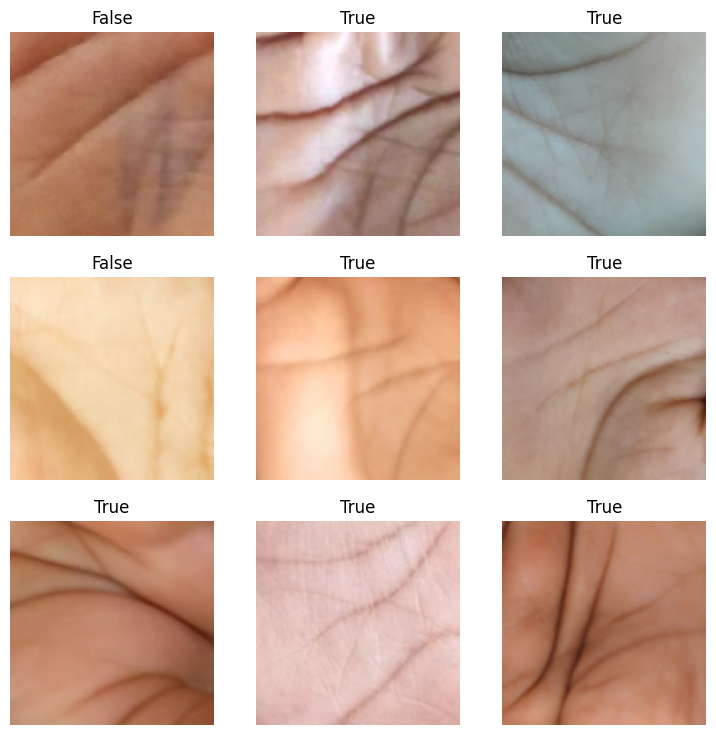

In [100]:
dls.show_batch()

In [101]:
learn1 = vision_learner(dls, 'resnet50', metrics=[accuracy, Precision(), Recall()], pretrained=True)

In [106]:
learn1.fine_tune(35)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,1.097121,0.684804,0.724178,0.775194,0.770713,00:04


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,0.711601,0.546165,0.762911,0.818913,0.784200,00:05
1,0.662126,0.439286,0.794601,0.839921,0.818882,00:05
2,0.603114,0.426652,0.796948,0.828897,0.840077,00:05
3,0.542887,0.383097,0.823944,0.841035,0.876686,00:05
4,0.496264,0.374281,0.838028,0.864245,0.870906,00:05
5,0.472853,0.352061,0.840376,0.862004,0.878613,00:05
6,0.459773,0.334382,0.856808,0.891519,0.870906,00:05
7,0.441548,0.335980,0.847418,0.871893,0.878613,00:05
8,0.406835,0.342323,0.852113,0.864564,0.897881,00:05
9,0.408458,0.354846,0.847418,0.858195,0.897881,00:05


In [107]:
learn1.tta()

(tensor([[0.9567, 0.0433],
         [0.3662, 0.6338],
         [0.9020, 0.0980],
         ...,
         [0.0037, 0.9963],
         [0.5957, 0.4043],
         [0.0448, 0.9552]]),
 tensor([0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
         0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
         1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
         0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
         1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
         1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
         0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
         0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
         1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
         1, 

In [108]:
learn1.predict(files[66])

('False', tensor(0), tensor([0.9779, 0.0221]))

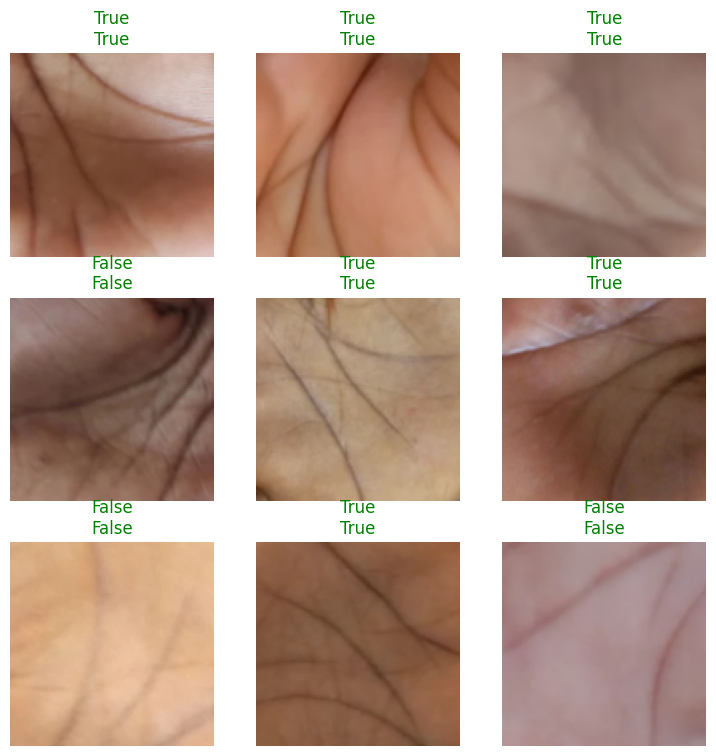

In [109]:
learn1.show_results()

In [110]:
learn1.export('/content/resnet50_model.pkl')

In [111]:
import os
os.listdir('/content')

['.config',
 'resnet50_weights.pth',
 'resnet50_model.pkl',
 'tabular_model2.pkl',
 'drive',
 'tabular_model1.pkl',
 'tabular_model3.pkl',
 'Palm',
 'sample_data']

In [112]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/resnet50_model.pkl /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
!cp /content/resnet50_weights.pth /content/drive/MyDrive/

In [114]:
import os

print("Saved Files:")
print(os.listdir())  # Lists all files in the current directory

Saved Files:
['.config', 'resnet50_weights.pth', 'resnet50_model.pkl', 'tabular_model2.pkl', 'drive', 'tabular_model1.pkl', 'tabular_model3.pkl', 'Palm', 'sample_data']


In [116]:
learn2 = vision_learner(dls, 'convnext_tiny', metrics=[accuracy, Precision(), Recall()], pretrained=True)

In [117]:
learn2.fine_tune(35)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,0.860305,0.526902,0.776995,0.798548,0.847784,00:04


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,0.486717,0.292124,0.881455,0.867958,0.949904,00:06
1,0.386944,0.230652,0.904930,0.892473,0.959538,00:06
2,0.298907,0.171499,0.928404,0.916364,0.971098,00:06
3,0.237946,0.123246,0.960094,0.954972,0.980732,00:06
4,0.182466,0.118808,0.953052,0.939450,0.986513,00:06
5,0.127427,0.074658,0.968310,0.965909,0.982659,00:06
6,0.092935,0.082019,0.980047,0.970037,0.998073,00:06
7,0.096335,0.069464,0.970657,0.982422,0.969171,00:06
8,0.076729,0.110738,0.956573,0.938182,0.994220,00:06
9,0.064982,0.117129,0.962441,0.950092,0.990366,00:06


In [118]:
learn2.predict(files[66])

('False', tensor(0), tensor([1.0000e+00, 1.3855e-06]))

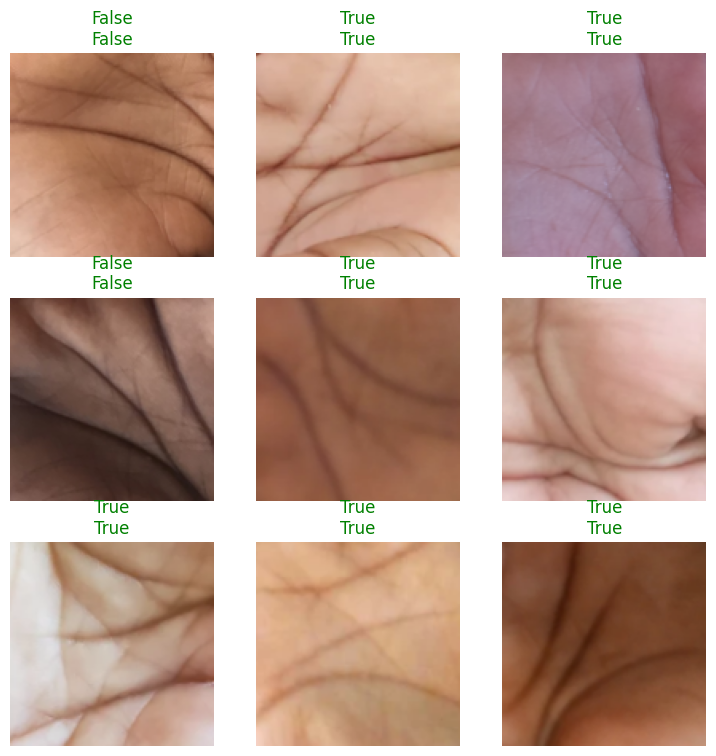

In [122]:
learn2.show_results()

In [121]:
learn2.tta()

(tensor([[9.9987e-01, 1.2755e-04],
         [1.0582e-01, 8.9418e-01],
         [9.9997e-01, 3.3294e-05],
         ...,
         [8.0182e-09, 1.0000e+00],
         [9.9998e-01, 2.4162e-05],
         [1.6616e-08, 1.0000e+00]]),
 tensor([0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
         0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
         1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
         0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
         1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
         1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
         0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
         0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
         1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 

In [123]:
# Export the entire Learner object (this saves the model, transforms, etc.)
learn2.export('/content/learn2_model.pkl')

# Save the model weights (state_dict) separately to a .pth file
torch.save(learn2.model.state_dict(), '/content/learn2_weights.pth')

In [124]:
from google.colab import drive
# Copy the saved model and weights to your Google Drive (replace 'MyDrive' with your preferred folder path)
!cp /content/learn2_model.pkl /content/drive/MyDrive/
!cp /content/learn2_weights.pth /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import timm
from fastai.vision.all import *

In [125]:
learn3 = vision_learner(dls, 'efficientnet_b3', metrics=[accuracy, Precision(), Recall()], pretrained=True)

In [127]:
learn3.fine_tune(35)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,0.115198,0.143192,0.944836,0.959144,0.949904,00:07


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,0.118949,0.144730,0.954225,0.959770,0.965318,00:08
1,0.123971,0.132602,0.951878,0.957854,0.963391,00:08
2,0.108657,0.125355,0.955399,0.956357,0.971098,00:08
3,0.091925,0.126062,0.956573,0.961686,0.967245,00:08
4,0.099660,0.139903,0.960094,0.961905,0.973025,00:08
5,0.093012,0.134370,0.947183,0.959302,0.953757,00:08
6,0.090088,0.139458,0.953052,0.963250,0.959538,00:08
7,0.089808,0.152698,0.949531,0.957692,0.959538,00:08
8,0.094547,0.156488,0.953052,0.963250,0.959538,00:08
9,0.094088,0.147027,0.951878,0.957854,0.963391,00:08


In [128]:
learn3.tta()

(tensor([[9.9964e-01, 3.5850e-04],
         [1.7807e-01, 8.2193e-01],
         [9.9737e-01, 2.6339e-03],
         ...,
         [1.7175e-03, 9.9828e-01],
         [9.9993e-01, 6.6124e-05],
         [2.1962e-02, 9.7804e-01]]),
 tensor([0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
         0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
         1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
         0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
         1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
         1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
         0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
         0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
         1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 

In [129]:
learn3.predict(files[77])

('True', tensor(1), tensor([1.2731e-04, 9.9987e-01]))

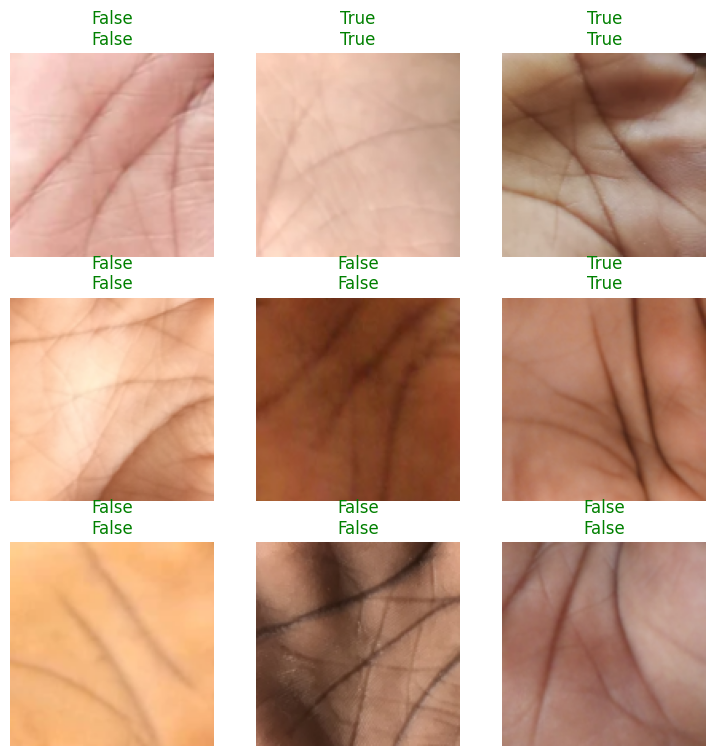

In [134]:
learn3.show_results()

In [135]:
learn3.export('/content/efficientnet_b3.pkl')

In [136]:
# Save the model weights (state_dict) separately to a .pth file
torch.save(learn3.model.state_dict(), '/content/learn3_weights.pth')

In [137]:
!cp /content/efficientnet_b3.pkl /content/drive/MyDrive/

In [140]:
from google.colab import drive
import torch
from fastai.vision.all import *

# Save the model weights (state_dict) separately to a .pth file
torch.save(learn3.model.state_dict(), '/content/efficientnet_b3_weights.pth')

# Mount Google Drive
drive.mount('/content/drive')

# Copy both files to Google Drive
!cp /content/efficientnet_b3.pkl /content/drive/MyDrive/
!cp /content/efficientnet_b3_weights.pth /content/drive/MyDrive/


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [141]:
# prompt: code to load all the three image models first

from fastai.vision.all import *
from fastai.tabular.all import *
import torch

# Load the three image models
learn1 = load_learner('/content/resnet50_model.pkl')
learn2 = load_learner('/content/learn2_model.pkl')
learn3 = load_learner('/content/efficientnet_b3.pkl')

print("✅ Image Model 1 Loaded:", learn1)
print("✅ Image Model 2 Loaded:", learn2)
print("✅ Image Model 3 Loaded:", learn3)


/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


✅ Image Model 1 Loaded: <fastai.learner.Learner object at 0x7b8a0c5bd050>
✅ Image Model 2 Loaded: <fastai.learner.Learner object at 0x7b8a0bff32d0>
✅ Image Model 3 Loaded: <fastai.learner.Learner object at 0x7b8a0c572e50>


In [142]:
# prompt: code to load all the 3 tabular models again

# Load the three tabular models
tabular_model1 = load_learner('/content/tabular_model1.pkl')
tabular_model2 = load_learner('/content/tabular_model2.pkl')
tabular_model3 = load_learner('/content/tabular_model3.pkl')

# Verify models are loaded
print("✅ Tabular Model 1 Loaded:", tabular_model1)
print("✅ Tabular Model 2 Loaded:", tabular_model2)
print("✅ Tabular Model 3 Loaded:", tabular_model3)


✅ Tabular Model 1 Loaded: <fastai.tabular.learner.TabularLearner object at 0x7b8846ac2e10>
✅ Tabular Model 2 Loaded: <fastai.tabular.learner.TabularLearner object at 0x7b8a067d1910>
✅ Tabular Model 3 Loaded: <fastai.tabular.learner.TabularLearner object at 0x7b8a0bf13b90>


/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
/usr/local/lib/python3.11/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you t

In [144]:
import numpy as np

def predict_ensemble(img_file):
    # Get predictions and probabilities from image models
    pred1, _, probs1 = learn1.predict(img_file)
    pred2, _, probs2 = learn2.predict(img_file)
    pred3, _, probs3 = learn3.predict(img_file)

    # Combine predictions using majority voting (mode)
    predictions = [pred1, pred2, pred3]
    combined_pred = max(set(predictions), key=predictions.count)

    # Combine probabilities for class "1" (anemic) by averaging
    probs_combined = np.mean([probs1[1].item(), probs2[1].item(), probs3[1].item()])

    return combined_pred, probs_combined

# Example usage
img_file = files[0]  # Replace with your image file
combined_pred, probs = predict_ensemble(img_file)

print(f"Combined Prediction: {combined_pred}")
print(f"Combined Probabilities: {probs}")

Combined Prediction: True
Combined Probabilities: 0.9986077944437662


In [ ]:
# Testing _ Image

In [146]:
# prompt: We've loaded all 3 tabular models right , now I need you to combine the y_predict of all the 3 tabular models

import pandas as pd
# Assuming 'tabular_model1', 'tabular_model2', and 'tabular_model3' are already loaded

# Example input data (replace with your actual data)
sample_cbc = {'Hemoglobin': 10.5, 'MCH': 22.1, 'MCHC': 28.7, 'MCV': 72.4}

# Convert to DataFrame
df = pd.DataFrame([sample_cbc])

# Get predictions
_, y_pred1, probs1 = tabular_model1.predict(df.iloc[0])
_, y_pred2, probs2 = tabular_model2.predict(df.iloc[0])
_, y_pred3, probs3 = tabular_model3.predict(df.iloc[0])

# Combine predictions (example: averaging probabilities)
combined_probs = (probs1 + probs2 + probs3) / 3

# Get the class with the highest average probability
combined_pred = combined_probs.argmax()

print(f"Combined Prediction: {combined_pred}")
print(f"Combined Probabilities: {combined_probs}")


Combined Prediction: 1
Combined Probabilities: tensor([5.5593e-04, 9.9944e-01])


In [157]:
import numpy as np

# Assuming y_predict_img1, y_predict_img2, y_predict_img3 are the predictions from the image models
# and y_predict_tab1, y_predict_tab2, y_predict_tab3 are from the tabular models.

# Replace with actual predictions (binary for image models, probabilities for tabular models)
y_predict_img1 = np.array([0, 1, 0, 1, 0])  # Example predictions from image model 1
y_predict_img2 = np.array([0, 0, 1, 1, 0])  # Example predictions from image model 2
y_predict_img3 = np.array([1, 1, 0, 1, 0])  # Example predictions from image model 3

# Example probabilities for tabular models (probability of class 1, i.e., "anemic")
y_predict_tab1 = np.array([0.2, 0.8, 0.1, 0.9, 0.3])
y_predict_tab2 = np.array([0.3, 0.7, 0.2, 0.8, 0.4])
y_predict_tab3 = np.array([0.1, 0.9, 0.3, 0.7, 0.2])

# Combine image model predictions (e.g., using majority voting)
combined_img_preds = np.array([np.argmax(np.bincount([p1, p2, p3])) for p1, p2, p3 in zip(y_predict_img1, y_predict_img2, y_predict_img3)])

# Calculate image model probabilities (e.g., average the probabilities of the "True" class)
img_probs = np.mean([y_predict_img1, y_predict_img2, y_predict_img3], axis=0)

# Combine tabular model predictions (e.g., averaging probabilities)
combined_tab_probs = np.mean([y_predict_tab1, y_predict_tab2, y_predict_tab3], axis=0)

# Convert tabular probabilities into binary predictions (True or False)
combined_tab_preds = (combined_tab_probs >= 0.5).astype(int)

# Confidence for tabular predictions (directly from the average probabilities)
tabular_confidence = combined_tab_probs

# Combine both sets of predictions (example: weighted average for final prediction)
image_weight = 0.7
tabular_weight = 0.3

# Weighted average of the final predictions
final_predictions = (image_weight * combined_img_preds) + (tabular_weight * combined_tab_preds)

# If you need 0 or 1 classification, round the final predictions
final_predictions = np.round(final_predictions).astype(int)

# Confidence for final predictions (based on weighted average of probabilities)
final_confidence = (image_weight * img_probs) + (tabular_weight * combined_tab_probs)

# Convert the results to True/False and show confidence % for image and tabular predictions
image_results = [(True if pred == 1 else False, prob * 100) for pred, prob in zip(combined_img_preds, img_probs)]
tabular_results = [(True if pred == 1 else False, prob * 100) for pred, prob in zip(combined_tab_preds, tabular_confidence)]
final_results = [(True if pred == 1 else False, prob * 100) for pred, prob in zip(final_predictions, final_confidence)]

# Print the results
print("Combined Image Predictions (True/False and Confidence %):")
for i, (result, prob) in enumerate(image_results):
    print(f"Sample {i+1}: {result}, Confidence: {prob:.2f}%")

print("\nCombined Tabular Predictions (True/False and Confidence %):")
for i, (result, prob) in enumerate(tabular_results):
    print(f"Sample {i+1}: {result}, Confidence: {prob:.2f}%")

print("\nFinal Combined Predictions (True/False and Confidence %):")
for i, (result, prob) in enumerate(final_results):
    print(f"Sample {i+1}: {result}, Confidence: {prob:.2f}%")


Combined Image Predictions (True/False and Confidence %):
Sample 1: False, Confidence: 33.33%
Sample 2: True, Confidence: 66.67%
Sample 3: False, Confidence: 33.33%
Sample 4: True, Confidence: 100.00%
Sample 5: False, Confidence: 0.00%

Combined Tabular Predictions (True/False and Confidence %):
Sample 1: False, Confidence: 20.00%
Sample 2: True, Confidence: 80.00%
Sample 3: False, Confidence: 20.00%
Sample 4: True, Confidence: 80.00%
Sample 5: False, Confidence: 30.00%

Final Combined Predictions (True/False and Confidence %):
Sample 1: False, Confidence: 29.33%
Sample 2: True, Confidence: 70.67%
Sample 3: False, Confidence: 29.33%
Sample 4: True, Confidence: 94.00%
Sample 5: False, Confidence: 9.00%


In [154]:
# prompt: code to copy all 3 tabular model to google drive

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Copy the tabular models to Google Drive
!cp /content/tabular_model1.pkl /content/drive/MyDrive/
!cp /content/tabular_model2.pkl /content/drive/MyDrive/
!cp /content/tabular_model3.pkl /content/drive/MyDrive/


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [158]:
# prompt: increase the final  prediction threshold greater than 0.7 like this "# Define the threshold for classification
# threshold = 0.7  # Set threshold to 70%
# # Apply thresholding on final confidence
# final_predictions = (final_confidence >= threshold).astype(int)  # 1 = True (Anemic), 0 = False (Non-Anemic)
# # Now you can print the final predictions
# print("Final Combined Predictions (True/False):")
# for i, (result, prob) in enumerate(zip(final_predictions, final_confidence)):
#     print(f"Sample {i+1}: {'True' if result == 1 else 'False'}, Confidence: {prob*100:.2f}%")
# "

# Define the threshold for classification
threshold = 0.7  # Set threshold to 70%

# Apply thresholding on final confidence
final_predictions = (final_confidence >= threshold).astype(int)  # 1 = True (Anemic), 0 = False (Non-Anemic)

# Now you can print the final predictions
print("Final Combined Predictions (True/False):")
for i, (result, prob) in enumerate(zip(final_predictions, final_confidence)):
    print(f"Sample {i+1}: {'True' if result == 1 else 'False'}, Confidence: {prob*100:.2f}%")


Final Combined Predictions (True/False):
Sample 1: False, Confidence: 29.33%
Sample 2: True, Confidence: 70.67%
Sample 3: False, Confidence: 29.33%
Sample 4: True, Confidence: 94.00%
Sample 5: False, Confidence: 9.00%


In [162]:
def ensemble_predict(img_file, cbc_data):
    """Combines predictions from image and tabular models.

    Args:
        img_file: Path to the image file.
        cbc_data: Dictionary containing CBC data (Hemoglobin, MCH, MCHC, MCV).

    Returns:
        Tuple: (Final Prediction (0 or 1), Confidence Score)
    """
    # Image model predictions
    img_preds = []
    img_probs = []
    for model in [learn1, learn2, learn3]:  # Use a list for easier iteration
        pred, _, prob = model.predict(img_file)
        img_preds.append(1 if pred == 'True' else 0)  # Convert boolean to int
        img_probs.append(prob[1].item())  # Probability of "anemic"

    combined_img_pred = max(set(img_preds), key=img_preds.count)  # Majority Voting
    avg_img_prob = np.mean(img_probs)

    # ... (rest of the code remains the same)

    # Tabular model predictions
    tab_probs = []
    df = pd.DataFrame([cbc_data])
    df = df[tabular_model1.dls.x_names] #Ensure consistent column order
    for model in [tabular_model1, tabular_model2, tabular_model3]:
      _, _, prob = model.predict(df.iloc[0])
      tab_probs.append(prob[1].item()) # Probability of "anemic"

    avg_tab_prob = np.mean(tab_probs)
    combined_tab_pred = int(avg_tab_prob >= 0.5)


    # Combine image and tabular predictions (e.g., weighted average)
    img_weight = 0.7
    tab_weight = 0.3

    final_prob = (img_weight * avg_img_prob) + (tab_weight * avg_tab_prob)
    final_pred = int(final_prob >= 0.75) #Final Prediction

    return final_pred, final_prob


# Example usage:
img_file = files[5]
cbc_data = {'Hemoglobin': 10.5, 'MCH': 22.1, 'MCHC': 28.7, 'MCV': 72.4}
prediction, confidence = ensemble_predict(img_file, cbc_data)

print(f"Ensemble Prediction: {prediction}")
print(f"Ensemble Confidence: {confidence:.4f}")


Ensemble Prediction: 0
Ensemble Confidence: 0.3047


In [ ]:
import pickle
from fastai.vision.all import *
from fastai.tabular.all import *
import pandas as pd
from pathlib import Path
import os
from fastai.tabular.all import load_learner
from fastai.data import *
from google.colab import drive, files
import timm
import torch
import numpy as np

# Assume the models are already trained and available as `learn1`, `learn2`, `learn3` (image models)
# and `tabular_model1`, `tabular_model2`, `tabular_model3` (tabular models)

# Ensemble prediction function that combines image and tabular model predictions
def ensemble_predict(img_file, cbc_data):
    """Combines predictions from image and tabular models."""
    # Image model predictions
    img_preds = []
    img_probs = []
    for model in [learn1, learn2, learn3]:  # Use a list for easier iteration
        pred, _, prob = model.predict(img_file)
        img_preds.append(1 if pred == 'True' else 0)  # Convert boolean to int
        img_probs.append(prob[1].item())  # Probability of "anemic"

    combined_img_pred = max(set(img_preds), key=img_preds.count)  # Majority Voting
    avg_img_prob = np.mean(img_probs)

    # Tabular model predictions
    tab_probs = []
    df = pd.DataFrame([cbc_data])
    df = df[tabular_model1.dls.x_names]  # Ensure consistent column order
    for model in [tabular_model1, tabular_model2, tabular_model3]:
        _, _, prob = model.predict(df.iloc[0])
        tab_probs.append(prob[1].item())  # Probability of "anemic"

    avg_tab_prob = np.mean(tab_probs)
    combined_tab_pred = int(avg_tab_prob >= 0.5)  # Classify as "True" if probability >= 0.5

    # Combine image and tabular predictions (e.g., weighted average)
    img_weight = 0.7
    tab_weight = 0.3

    final_prob = (img_weight * avg_img_prob) + (tab_weight * avg_tab_prob)
    final_pred = int(final_prob >= 0.75)  # Final Prediction: "True" if probability >= 0.75

    return final_pred, final_prob


# Upload files using Google Colab
uploaded_files = files.upload()  # This will return a dictionary of uploaded files

# Extract image paths from the uploaded files dictionary (the keys are the file names)
image_paths = [str(file) for file in uploaded_files.keys()]

# Create a dictionary to store all the necessary objects
ensemble_model_data = {
    'learn1': learn1,
    'learn2': learn2,
    'learn3': learn3,
    'tabular_model1': tabular_model1,
    'tabular_model2': tabular_model2,
    'tabular_model3': tabular_model3,
    'ensemble_predict': ensemble_predict,
    'image_paths': image_paths  # Save the image paths from the uploaded files
}

# Save the dictionary to a pickle file
with open('/content/ensemble_model.pkl', 'wb') as f:
    pickle.dump(ensemble_model_data, f)

print("Ensemble model saved to /content/ensemble_model.pkl")

# To load the saved model:

with open('/content/ensemble_model.pkl', 'rb') as f:
    loaded_ensemble = pickle.load(f)

learn1 = loaded_ensemble['learn1']
learn2 = loaded_ensemble['learn2']
learn3 = loaded_ensemble['learn3']
tabular_model1 = loaded_ensemble['tabular_model1']
tabular_model2 = loaded_ensemble['tabular_model2']
tabular_model3 = loaded_ensemble['tabular_model3']
ensemble_predict_function = loaded_ensemble['ensemble_predict']
image_paths = loaded_ensemble['image_paths']  # Loaded image paths

# Example usage of the loaded model:
img_file = Path(image_paths[5])  # Accessing the 6th image (example)
cbc_data = {'Hemoglobin': 10.5, 'MCH': 22.1, 'MCHC': 28.7, 'MCV': 72.4}

# Predict using the ensemble function
prediction, confidence = ensemble_predict_function(img_file, cbc_data)

print(f"Ensemble Prediction: {prediction}")
print(f"Ensemble Confidence: {confidence:.4f}")
